## Lab6-Assignment: Topic Classification

Use the same training, development, and test partitions of the the 20 newsgroups text dataset as in Lab6.4-Topic-classification-BERT.ipynb

* Fine-tune and examine the performance of another transformer-based pretrained language models, e.g., RoBERTa, XLNet

* Compare the performance of this model to the results achieved in Lab6.4-Topic-classification-BERT.ipynb and to a conventional machine learning approach (e.g., SVM, Naive Bayes) using bag-of-words or other engineered features of your choice.
Describe the differences in performance in terms of Precision, Recall, and F1-score evaluation metrics.

In [ ]:
# %pip install simpletransformers

### Data Preprocessing

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import sklearn
from sklearn.metrics import classification_report
#from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt
import seaborn as sn

In [ ]:
from sklearn.datasets import fetch_20newsgroups

# load only a sub-selection of the categories (4 in our case)
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space']

# remove the headers, footers and quotes (to avoid overfitting)
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)

In [ ]:
from collections import Counter
Counter(newsgroups_train.target)

Counter({2: 594, 3: 593, 1: 584, 0: 480})

In [ ]:
# Convert data to pandas dataframe
train = pd.DataFrame({'text': newsgroups_train.data, 'labels': newsgroups_train.target})
test = pd.DataFrame({'text': newsgroups_test.data, 'labels': newsgroups_test.target})

In [ ]:
# Validation selection, 10% of training data
from sklearn.model_selection import train_test_split

train, dev = train_test_split(train, test_size=0.1, random_state=0,
                               stratify=train[['labels']])

### Model RoBERTa

In [ ]:
# Model configuration # https://simpletransformers.ai/docs/usage/#configuring-a-simple-transformers-model
model_args = ClassificationArgs()

model_args.overwrite_output_dir=True # overwrite existing saved models in the same directory
model_args.evaluate_during_training=True # to perform evaluation while training the model
# (eval data should be passed to the training method)

model_args.num_train_epochs=10 # number of epochs
model_args.train_batch_size=32 # batch size
model_args.learning_rate=4e-6 # learning rate
model_args.max_seq_length=256 # maximum sequence length
# Note! Increasing max_seq_len may provide better performance, but training time will increase.
# For educational purposes, we set max_seq_len to 256.

# Early stopping to combat overfitting: https://simpletransformers.ai/docs/tips-and-tricks/#using-early-stopping
model_args.use_early_stopping=True
model_args.early_stopping_delta=0.01 # "The improvement over best_eval_loss necessary to count as a better checkpoint"
model_args.early_stopping_metric='eval_loss'
model_args.early_stopping_metric_minimize=True
model_args.early_stopping_patience=2
model_args.evaluate_during_training_steps=32 # how often you want to run validation in terms of training steps (or batches)

In [ ]:
# Checking steps per epoch
steps_per_epoch = int(np.ceil(len(train) / float(model_args.train_batch_size)))
print('Each epoch will have {:,} steps.'.format(steps_per_epoch)) # 64 steps = validating 2 times per epoch

Each epoch will have 64 steps.


In [ ]:
# We will be using RoBERTa
model = ClassificationModel('roberta', 'FacebookAI/roberta-base', num_labels=4, args=model_args, use_cuda=True) # CUDA is enabled

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [ ]:
print(str(model.args).replace(',', '\n')) # model args

ClassificationArgs(adafactor_beta1=None
 adafactor_clip_threshold=1.0
 adafactor_decay_rate=-0.8
 adafactor_eps=(1e-30
 0.001)
 adafactor_relative_step=True
 adafactor_scale_parameter=True
 adafactor_warmup_init=True
 adam_betas=(0.9
 0.999)
 adam_epsilon=1e-08
 best_model_dir='outputs/best_model'
 cache_dir='cache_dir/'
 config={}
 cosine_schedule_num_cycles=0.5
 custom_layer_parameters=[]
 custom_parameter_groups=[]
 dataloader_num_workers=0
 do_lower_case=False
 dynamic_quantize=False
 early_stopping_consider_epochs=False
 early_stopping_delta=0.01
 early_stopping_metric='eval_loss'
 early_stopping_metric_minimize=True
 early_stopping_patience=2
 encoding=None
 eval_batch_size=100
 evaluate_during_training=True
 evaluate_during_training_silent=True
 evaluate_during_training_steps=32
 evaluate_during_training_verbose=False
 evaluate_each_epoch=True
 fp16=True
 gradient_accumulation_steps=1
 learning_rate=4e-06
 local_rank=-1
 logging_steps=50
 loss_type=None
 loss_args={}
 manual_see

In [ ]:
# Finetuning the model
_, history = model.train_model(train, eval_df=dev)


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:882: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


Running Epoch 1 of 10:   0%|          | 0/64 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:905: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


...

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:905: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


0it [00:00, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:1505: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:905: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


0it [00:00, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:1505: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


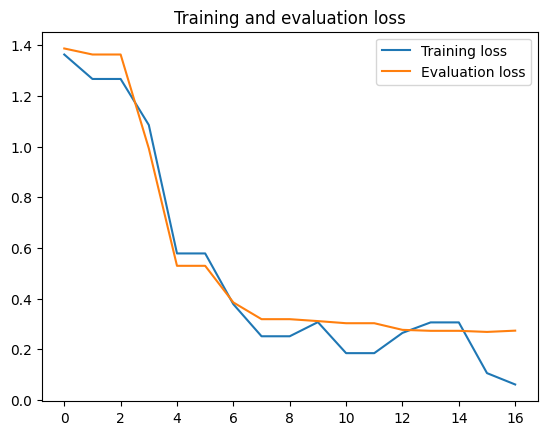

In [ ]:
# Training and evaluation loss
train_loss = history['train_loss']
eval_loss = history['eval_loss']
plt.plot(train_loss, label='Training loss')
plt.plot(eval_loss, label='Evaluation loss')
plt.title('Training and evaluation loss')
plt.legend()

### Evaluation

In [ ]:
# Evaluate the model
result, model_outputs, wrong_predictions = model.eval_model(dev)
result

0it [00:00, ?it/s]

Running Evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:1505: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


{'mcc': 0.8532684074746885, 'eval_loss': 0.2732365181048711}

In [ ]:
predicted, probabilities = model.predict(test.text.to_list())
test['predicted'] = predicted

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/simpletransformers/classification/classification_model.py:2188: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


In [ ]:
test.head(5)

,text,labels,predicted
0,\nAnd guess who's here in your place.\n\nPleas...,1,1
1,Does anyone know if any of Currier and Ives et...,1,1
2,=FLAME ON\n=\n=Reading through the posts about...,2,2
3,\nBut in this case I said I hoped that BCCI wa...,0,0
4,\nIn the kind I have made I used a Lite sour c...,2,2


In [ ]:
# Result (note: your result can be different due to randomness in operations)
print(classification_report(test['labels'], test['predicted']))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82       319
           1       0.89      0.92      0.90       389
           2       0.85      0.92      0.88       396
           3       0.87      0.80      0.83       394

    accuracy                           0.86      1498
   macro avg       0.86      0.86      0.86      1498
weighted avg       0.86      0.86      0.86      1498



### Examination
The classification report provides three evaluation metrics: precision, recall, and F1-score.
The precision measures how many of the instances predicted as a certain class belong to that class. For example, how many of the instances classified as label 0, were actually label 0.
The recall measures how many instances of the class were correctly identified. For example, how many of instances belonging to the 0 label were identified as label 0.
The F1-score provides a balance between precision and recall. A high F1-score means a good performance in both precision and recall. <br>
When examining this classification report, we can see that the model performs quite well along the 3 evalution metrics. Notably, label 0 performs the worst: it has the lowest score for precision and F1-score. This suggests that label 0 has a higher number of misclassifications compared to other categories. However, label 3 scores the lowest on recall with 0.8. Label 1 has the highest scores for all tests: a 0.89 for precision, a 0.92 for recall, and 0.9 for F1-score.
A possible explanation for label 0's weaker performance is the imbalance in training data. When examining the training data, label 0 has over 100 fewer instances compared to other categories. This may have led to poorer generalization by the model.

### Comparing RoBERTa to BERT

Now, we compare the performance of our RoBERTa model to the performance of the BERT model from `Lab6.4_Topic_classification_BERT.ipynb`. Below, you will find the classification report we generated to evaluate the performance of the BERT model on the test set.

```
              precision    recall   f1-score   support

           0       0.84      0.82      0.83       319
           1       0.90      0.91      0.90       389
           2       0.85      0.91      0.88       396
           3       0.87      0.81      0.84       394

    accuracy                           0.87      1498
   macro avg       0.87      0.87      0.87      1498
weighted avg       0.87      0.87      0.87      1498
```



**Precision:**  Both models demonstrate equal precision on class 2 and class 3 (0.85 and 0.87, respectively). However, the BERT model slightly outperforms the RoBERTA model on class 0 and class 1 in terms of precision (0.84 versus 0.83 and 0.90 versus 0.89, respectively). This suggests that when the BERT model predicts a class, its positive predictions for class 0 and class 1 are marginally more reliable than those of the RoBERTa model.   <br>
**Recall:**   We only observe two higher scores for the RoBERTa model when we look at the recall by class. The RoBERTa model has higher recall for class 1 and class 2 (0.92 versus 0.91 for both classes). However, these differences are marginal, and BERT has slightly higher recall for class 0 and class 3 (0.82 versus 0.81 and 0.81 versus 0.80). This means that the RoBERTa model is slightly better at capturing all actual positives in class 1 and class 2, whereas the BERT model detects marginally more actual positive instances of class 0 and class 3.   <br>
**F1-score:**  While both models have equal F1-scores on class 1 and class 2 (0.90 and 0.88, respectively), the BERT model shows marginally higher scores on class 0 and class 3 (0.83 versus 0.82 and 0.84 versus 0.83, respectively). This indicates that the harmonic balance of precision and recall is slightly higher for the BERT model for classes 0 and 3 when compared to the RoBERTa model.  <br>
<br>
**Conclusion:**   The BERT model slightly outperforms the RoBERTa model (most notably on class 0 and class 3) as the BERT model has higher overall accuracy, and higher macro average and weighted average for  precision, recall, and f1-score than the RoBERTA model (0.87 to BERT versus 0.86 to RoBERTa for each score), though the differences are marginal and might not be statistically significant.   <br>

# Multinomial Naive Bayes

In [ ]:
#Import additional libraries needed for this part
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.datasets import fetch_20newsgroups

# load only a sub-selection of the categories (4 in our case)
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space']

# remove the headers, footers and quotes (to avoid overfitting)
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)

In [ ]:
# Convert data to pandas dataframe
train = pd.DataFrame({'text': newsgroups_train.data, 'labels': newsgroups_train.target})
test = pd.DataFrame({'text': newsgroups_test.data, 'labels': newsgroups_test.target})

In [ ]:
# Validation selection, 10% of training data
from sklearn.model_selection import train_test_split

train, dev = train_test_split(train, test_size=0.1, random_state=0,
                               stratify=train[['labels']])

In [ ]:
#Bag of Words with Multinomial Naive Bayes
nb_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(max_features=10000)),
    ('classifier', MultinomialNB())
])

In [ ]:
#Training the model
nb_pipeline.fit(train['text'], train['labels'])

Pipeline(steps=[('vectorizer', CountVectorizer(max_features=10000)),
                ('classifier', MultinomialNB())])

In [ ]:
nb_predictions = nb_pipeline.predict(test['text'])

In [ ]:
print("Naive Bayes with Bag of Words:")
print(classification_report(test['labels'], nb_predictions))

Naive Bayes with Bag of Words:
              precision    recall  f1-score   support

           0       0.75      0.89      0.81       319
           1       0.91      0.87      0.89       389
           2       0.83      0.85      0.84       396
           3       0.88      0.76      0.82       394

    accuracy                           0.84      1498
   macro avg       0.84      0.84      0.84      1498
weighted avg       0.85      0.84      0.84      1498



## Comparison of RoBERTa and Naive Bayes

**Precision**
The RoBERTa model demonstrated slightly higher overall precision than the Naive Bayes model. RoBERTa acheives a weighted average percision of 0.86 compared to Naive Bayes' 0.85. Looking at the individual classes, RoBERTa performs better for classes 0 and 2, while Naive Bayes shows higher precision for classes 1 and 3. This suggests that when the Naive Bayes model predicts a document belongs to classes 1 or 3, it is slightly more likely to be correct than RoBERTa, but RoBERTa is slightly more precise overall.

**Recall**
For recall, the models show interesting differences across classes. RoBERTa has a better overall recall (0.86) compared to Naive Bayes (0.84). However, Naive Bayes significantly outperfoems RoBERTa on class 0 with a recall of 0.89 vs. 0.81. This means Naive Bayes is better at identifying documents that actually belong to class 0. For the remaining classes, RoBERTa shows a stronger recall, particularly for classes 2 and 3. RoBERTa's more balanced recall across classes indicates its better at finding relevant documents across all topics.

**F1-score**
The F1-score, which balances precision and recall, reveals that RoBERTa performs slightly better overall with a weighted average of 0.86 compared to Naive Bayes' 0.84. The difference is most apparent in class 2, where RoBERTa acheives an F1-score of 0.88 vs. Naive Bayes' 0.84. Both models performs almost identically on classes 0 and 3. For class 1, the models are extremely close, with RoBERTa having a slight edge. This suggests that despite its much greated complexity, RoBERTa only moderately outperforms Naive Bayes in terms of balanced performance.

These results demonstrate the interesting trade-off between model complexity and performance. Despite RoBERTa's sophisticated architecture and contextual understanding, it only moderately outperforms the simpler Naive Bayes model. This suggests that for this classification task, basic word frequencies already provide strong signals about document categories. RoBERTa's advantage comes from capturing subtler semantic relationships that bag of words appoaches miss, but the performance gap doesnt necessarily justify the sustantially higher computational cost for all applications.  